> Module: Deep learning<br>
> Lab: 3<br>
> Name: Chun-Yuan Chen<br>

# Recommender Systems

In this lab, we'll be using Keras to build a recommender system. We'll be using the MovieLens dataset, a common benchmark dataset for recommender systems. 

MovieLens is a web-based recommender system and virtual community that recommends movies for its users to watch, based on their film preferences using collaborative filtering of members' movie ratings and movie reviews. You can check out the website here: https://movielens.org/

We will download a subset of the dataset containing 100k ratings. There are tens of millions of ratings in the full dataset, spanning hundreds of thousands of users and movies. The subset we'll be using is a good example to demonstrate the concepts in this lab.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from zipfile import ZipFile
from urllib.request import urlretrieve # download files from the internet
from pathlib import Path

ML_100K_URL = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
ML_100K_FILENAME = Path("ml-100k.zip") # name the downloaded file
ML_100K_FOLDER = Path("ml-100k") # name the downloaded folder

if not ML_100K_FOLDER.exists():
    if not ML_100K_FILENAME.exists():
        urlretrieve(ML_100K_URL, ML_100K_FILENAME.name)
    with ZipFile(ML_100K_FILENAME.name) as zip_file:
        zip_file.extractall()

The goal of MovieLens is to enable models to predict the rating a user would give to a movie they have not yet watched. This is a classic example of a recommendation system. The dataset is huge, and contains many parts giving information about the movies, the users, and the ratings. To begin with, we will look at the ratings file. Each line in the ratings file (u.data) is formatted as:

`user_id, item_id, rating, timestamp`

Which tells us a single user's rating of a single movie.

We will start by loading the ratings data into a pandas dataframe and then take a look at the first few rows. If you haven't used Pandas before, it's an extremely powerful library for dealing with tabular data. You can think of it as a Python version of Excel.

In [2]:
import pandas as pd

raw_ratings = pd.read_csv(ML_100K_FOLDER / "u.data", sep='\t', names=["user_id", "item_id", "rating", "timestamp"])
raw_ratings

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


The second file we'll look at is the movie metadata. This file (u.item) contains information about each movie, including the title and release date. Each line in the file is formatted as:

`movie_id | movie_title | release_date | video_release_date | IMDb_URL | unknown | Action | Adventure | Animation | Children's | Comedy | Crime | Documentary | Drama | Fantasy | Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi | Thriller | War | Western`

As you can see, the genres are binary variables. As with one-hot encoding, a 1 indicates that the movie is of that genre, and a 0 indicates that it is not. We aren't going to work with the genre data in this lab, but it's easy to imagine that it could be useful in a real-world recommendation system.

In [3]:
columns_to_keep = ['item_id', 'title', 'release_date', 'video_release_date', 'imdb_url']
items = pd.read_csv(ML_100K_FOLDER / "u.item", sep='|', names=columns_to_keep, encoding='latin-1', usecols=range(5))
items

,item_id,title,release_date,video_release_date,imdb_url
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995)
...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998)
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...


By default, the `release_date` column is a string. We can convert it to a `datetime` object using the `pd.to_datetime` function. This will make it easier to work with in the future (if we want to do things like check which date came first, for example).
 
We can also extract the year from the date and store it in a separate column. This will make it easier to do things like plot the number of movies released each year.

In [4]:
items['release_date'] = pd.to_datetime(items['release_date']) # Pandas makes this easy!
items['release_year'] = items['release_date'].dt.year # For later use

For our purposes, it will be easier to work with the data if we merge our two dataframes into a single dataframe. We can do this using the `merge` method. We'll merge the `items` dataframe into the `raw_ratings` dataframe, using the `item_id` column as the key. This will add the movie title and release year to each rating.

In [5]:
all_ratings = pd.merge(items, raw_ratings)

In [6]:
all_ratings.head()

,item_id,title,release_date,video_release_date,imdb_url,release_year,user_id,rating,timestamp
0,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,308,4,887736532
1,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,287,5,875334088
2,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,148,4,877019411
3,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,280,4,891700426
4,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,66,3,883601324


### Data preprocessing

It's always important to understand the data you've collected. Thankfully, Pandas continues to make this easy for us. Using the `describe` method, we can get a quick statistical summary of the data.

In [7]:
all_ratings.describe()

,item_id,release_date,video_release_date,release_year,user_id,rating,timestamp
count,100000.000000,99991,0.0,99991.000000,100000.00000,100000.000000,1.000000e+05
mean,425.530130,1988-02-09 00:43:11.369223296,NaN,1987.956216,462.48475,3.529860,8.835289e+08
min,1.000000,1922-01-01 00:00:00,NaN,1922.000000,1.00000,1.000000,8.747247e+08
25%,175.000000,1986-01-01 00:00:00,NaN,1986.000000,254.00000,3.000000,8.794487e+08
50%,322.000000,1994-01-01 00:00:00,NaN,1994.000000,447.00000,4.000000,8.828269e+08
75%,631.000000,1996-09-28 00:00:00,NaN,1996.000000,682.00000,4.000000,8.882600e+08
max,1682.000000,1998-10-23 00:00:00,NaN,1998.000000,943.00000,5.000000,8.932866e+08
std,330.798356,NaN,NaN,14.155523,266.61442,1.125674,5.343856e+06


Let's do a bit more pandas magic to compute the popularity of each movie (number of ratings). We will use the `groupby` method to group the dataframe by the `item_id` column and then use the `size` method to compute the number of ratings for each movie. We will use the `reset_index` method to convert the resulting Series into a dataframe with an `item_id` column.

In [8]:
popularity = all_ratings.groupby('item_id').size().reset_index(name='popularity')
items = pd.merge(popularity, items)

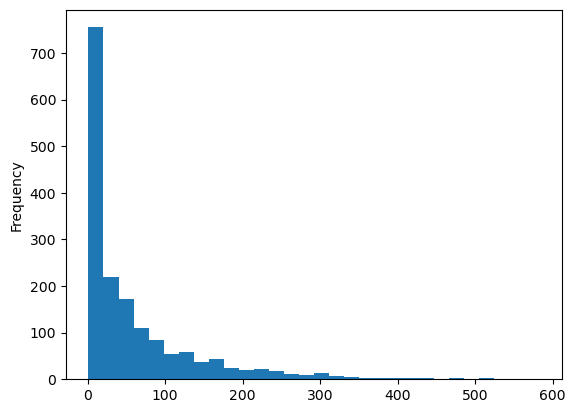

In [9]:
items['popularity'].plot.hist(bins=30);

In [10]:
(items['popularity'] == 1).sum() # Number of movies with only one rating

np.int64(141)

In [11]:
items.nlargest(10, 'popularity')['title'] # Get the 10 most popular movies

49                  Star Wars (1977)
257                   Contact (1997)
99                      Fargo (1996)
180        Return of the Jedi (1983)
293                 Liar Liar (1997)
285      English Patient, The (1996)
287                    Scream (1996)
0                   Toy Story (1995)
299             Air Force One (1997)
120    Independence Day (ID4) (1996)
Name: title, dtype: object

In [12]:
all_ratings = pd.merge(popularity, all_ratings)
all_ratings.describe()

,item_id,popularity,release_date,video_release_date,release_year,user_id,rating,timestamp
count,100000.000000,100000.000000,99991,0.0,99991.000000,100000.00000,100000.000000,1.000000e+05
mean,425.530130,168.071900,1988-02-09 00:43:11.369223296,NaN,1987.956216,462.48475,3.529860,8.835289e+08
min,1.000000,1.000000,1922-01-01 00:00:00,NaN,1922.000000,1.00000,1.000000,8.747247e+08
25%,175.000000,71.000000,1986-01-01 00:00:00,NaN,1986.000000,254.00000,3.000000,8.794487e+08
50%,322.000000,145.000000,1994-01-01 00:00:00,NaN,1994.000000,447.00000,4.000000,8.828269e+08
75%,631.000000,239.000000,1996-09-28 00:00:00,NaN,1996.000000,682.00000,4.000000,8.882600e+08
max,1682.000000,583.000000,1998-10-23 00:00:00,NaN,1998.000000,943.00000,5.000000,8.932866e+08
std,330.798356,121.784558,NaN,NaN,14.155523,266.61442,1.125674,5.343856e+06


In [13]:
indexed_items = items.set_index('item_id')

In [14]:
all_ratings.head()

,item_id,popularity,title,release_date,video_release_date,imdb_url,release_year,user_id,rating,timestamp
0,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,308,4,887736532
1,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,287,5,875334088
2,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,148,4,877019411
3,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,280,4,891700426
4,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,66,3,883601324


**Quick Exercise**:

As we have seen, the `groupby` method is a powerful tool to quickly compute statistics on the data. Use it to compute the average rating for each movie.

**Hint**: you can use the `mean` method after the `groupby` method.

In [18]:
# raise NotImplementedError("Please calculate the average rating for each movie")
average_ratings = all_ratings.groupby("title")["rating"].mean()
average_ratings

title
'Til There Was You (1997)                2.333333
1-900 (1994)                             2.600000
101 Dalmatians (1996)                    2.908257
12 Angry Men (1957)                      4.344000
187 (1997)                               3.024390
                                           ...   
Young Guns II (1990)                     2.772727
Young Poisoner's Handbook, The (1995)    3.341463
Zeus and Roxanne (1997)                  2.166667
unknown                                  3.444444
Á köldum klaka (Cold Fever) (1994)       3.000000
Name: rating, Length: 1664, dtype: float64

Let's split the enriched data in a train / test split to make it possible to do predictive modeling:

In [19]:
from sklearn.model_selection import train_test_split

ratings_train, ratings_test = train_test_split(all_ratings, test_size=0.2, random_state=0)

user_id_train = np.array(ratings_train['user_id'])
item_id_train = np.array(ratings_train['item_id'])
rating_train = np.array(ratings_train['rating'])

user_id_test = np.array(ratings_test['user_id'])
item_id_test = np.array(ratings_test['item_id'])
rating_test = np.array(ratings_test['rating'])

# Explicit feedback: supervised ratings prediction

Now let's begin to do some recommendation! We will build a model that takes a user and a movie as input and outputs a predicted rating. We will be taking advantage of embeddings to represent users and movies. That means that each movie and user will have an abstract representation in a continuous vector space. The model will learn these representations based on the ratings.

## Predictive ratings  as a regression problem

The following code implements the following architecture:

<img src="https://raw.githubusercontent.com/UofT-DSI/deep_learning/refs/heads/main/01_materials/labs/images/rec_archi_1.svg" style="width: 600px;" />

In [20]:
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
from tensorflow.keras.layers import Dot
from tensorflow.keras.models import Model

In [21]:
# For each sample we input the integer identifiers
# of a single user and a single item

# Building a simple neural network model to predict how much a user will like a movie using just the user ID and movie ID as input.
# This is a custom model that uses embeddings to represent users and items (movies) as vectors.
# Then, predicts a rating by computing the dot product between those vectors.

class RegressionModel(Model):
    def __init__(self, embedding_size, max_user_id, max_item_id):
        # embedding_size: how big each user/movie vector should be.
        # max_user_id: the highest user ID in the data.
        # max_item_id: the highest movie ID in the data.

        super().__init__()
        
        self.user_embedding = Embedding(output_dim=embedding_size, input_dim=max_user_id + 1, name='user_embedding')
        # creates an embedding layer for users.
        # turns each user ID into a vector of size embedding_size.
        # input_dim=max_user_id + 1 ensures all user IDs are covered (since IDs start at 0).

        self.item_embedding = Embedding(output_dim=embedding_size, input_dim=max_item_id + 1, name='item_embedding')
        # Same as above, but for movies (items). Each movie ID becomes a vector too.

        # The following two layers don't have parameters.
        self.flatten = Flatten() # This layer flattens the output from the embedding (which is 2D) into a 1D vector, so it can be used in math operations.
        self.dot = Dot(axes=1) # This layer takes two vectors (user and movie) and computes their dot product, a single number that represents how similar they are. That number is the predicted rating.

    # Run the model: forward pass    
    def call(self, inputs): 
        user_inputs = inputs[0] # user ID input 
        item_inputs = inputs[1] # movie ID input
        
        user_vecs = self.flatten(self.user_embedding(user_inputs))
        item_vecs = self.flatten(self.item_embedding(item_inputs))
        # the embedding (vector) for each user and movie, and flatten the result into 1D vectors.
        
        y = self.dot([user_vecs, item_vecs])
        # calculates the dot product between the user and movie vectors.
        return y # Returns the predicted rating.


model = RegressionModel(embedding_size=64, max_user_id=all_ratings['user_id'].max(), max_item_id=all_ratings['item_id'].max())
# Create a model, uses 64-dimensional vectors, and sets the max user and movie IDs based on the dataset.
# Bigger embedding_size >>> more room to capture patterns. 64 is often a good trying start for small-to-medium datasets.

model.compile(optimizer="adam", loss='mae')
# Uses the Adam optimizer and mean absolute error as the loss.

### Monitoring runs

When training a model with Keras, we get a `history` object back that contains lots of information about the training run. We can use this to plot the training and validation loss to see how the model has improved during training.

In [22]:
%%time 
# measures how long the cell takes to run.

# Training the model
history = model.fit([user_id_train, item_id_train], rating_train, batch_size=64, epochs=10, validation_split=0.1, shuffle=True)
    # [user_id_train, item_id_train]: user IDs and movie IDs inputs
    # rating_train: actual ratings target
    # batch_size=64: train 64 samples at a time
    # epochs=10: go through the entire dataset 10 times
    # validation_split=0.1: use 10% of the training data to validate performance
    # shuffle=True: shuffle data before each epoch to improve learning

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.3088 - val_loss: 1.0576
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9121 - val_loss: 0.7973
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7526 - val_loss: 0.7673
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7169 - val_loss: 0.7518
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6923 - val_loss: 0.7451
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6707 - val_loss: 0.7346
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6465 - val_loss: 0.7387
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6235 - val_loss: 0.7366
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6018 - val_loss: 0.7371
Epoch 10/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5783 - val_loss: 0.7403
CPU times: total: 34.5 s
Wall time: 21.5 s


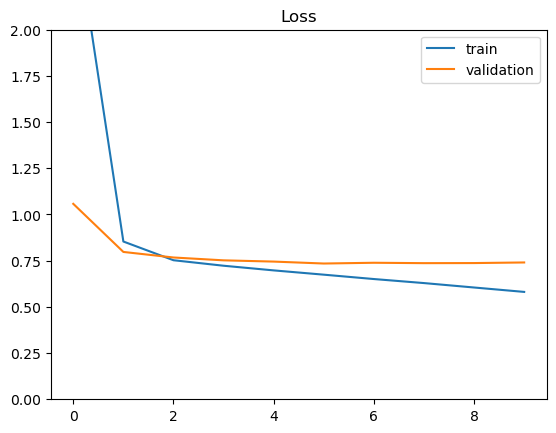

In [23]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss');

**Questions**:

- Does it look like our model has overfit? Why or why not?  
Your Answer: Yes. Based on the above figure, we can see that loss during training keeps decreasing, but loss during validation keep flattened and even rised. In other words, too good performance on training, poor performance on validation.
- Suggest something we could do to prevent overfitting.  
Your Answer: May apply dropout or reduce embedding size.

Now that the model is trained, let's check out the quality of predictions:

In [24]:
def plot_predictions(y_true, y_pred):
    plt.figure(figsize=(4, 4))
    plt.xlim(-1, 6)
    plt.xlabel("True rating")
    plt.ylim(-1, 6)
    plt.ylabel("Predicted rating")
    plt.scatter(y_true, y_pred, s=60, alpha=0.01)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final test MSE: 0.909
Final test MAE: 0.737


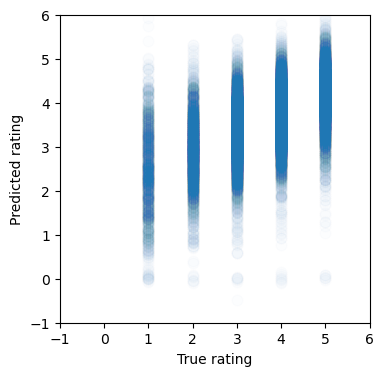

In [25]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

test_preds = model.predict([user_id_test, item_id_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))
plot_predictions(rating_test, test_preds)

This graph shows us the range of predicted ratings our model gives, organized by the true rating. We can see that generally, the higher the true rating the higher the predicted rating, although there is quite a range of predictions for each instance. That's okay - our model is very simple, and human preferences are very complex!

Taking a look at the Mean Absolute Error, hopefully you got something around 0.75. This means that, on average, our predicted ratings are about 0.75 stars off from the true ratings. This is a pretty good result for a first attempt. We could probably do better with a more complex model, but we'll leave that for another time.

### Model Embeddings

Our model was built with two embedding layers. These layers have learned a representation of both the users and the movies in our dataset. We can extract these representations and use them to find similar movies or users. We can also do interesting exploratory analysis, like finding the most popular movies among our users, or finding the users that are most interested in a given movie.

In [26]:
# weights and shape
weights = model.get_weights() # grabs all the weights from the trained model
[w.shape for w in weights] # loops through each weight and shows its shape

[(944, 64), (1683, 64)]

> CYC notes:<br>
> Based on the above output, (944, 64) represents 944 users, each with a 64-dimensional vector; (1683, 64) represents 1683 movies, each also with a 64-dimensional vector.

In [27]:
user_embeddings = weights[0] # grabs the user embedding matrix
item_embeddings = weights[1] # grabs the movie embedding matrix

In [ ]:
user_embeddings # each row is a vector representing one user.

array([[ 0.01561724, -0.04715933, -0.0258567 , ..., -0.04046987,
        -0.01964736,  0.01595742],
       [ 0.21945262,  0.35861942, -0.10394492, ...,  0.27619505,
         0.24145336,  0.03838654],
       [-0.09715439,  0.25246942,  0.18606198, ...,  0.17894   ,
         0.37858415,  0.21756406],
       ...,
       [-0.24044903,  0.32757387,  0.17188123, ...,  0.28080493,
         0.28600115,  0.17534997],
       [-0.02426372,  0.4892612 , -0.02588429, ...,  0.18702123,
         0.24913336, -0.16499478],
       [-0.7662312 ,  0.23204947, -0.33918428, ...,  0.4919475 ,
         0.2586536 ,  0.49049854]], dtype=float32)

In [29]:
item_embeddings # each row is a vector representing one movie

array([[ 0.04058141, -0.01641139,  0.03244639, ...,  0.04904327,
        -0.03115829, -0.04040631],
       [-0.11303394,  0.40497527,  0.0326413 , ...,  0.20773873,
         0.30157566,  0.13628414],
       [-0.10311944,  0.0934763 , -0.04259196, ...,  0.14598086,
         0.06120761,  0.19359703],
       ...,
       [-0.09376812,  0.12996432,  0.0816206 , ...,  0.1176517 ,
         0.18267211,  0.18570265],
       [ 0.13599037,  0.16162561, -0.17453325, ...,  0.22788389,
         0.19252184,  0.16165082],
       [ 0.19342995,  0.19079478,  0.24160178, ...,  0.17481568,
         0.15983237, -0.25799125]], dtype=float32)

In [30]:
item_id = 181 # the movie' ID
print(f"Title for item_id={item_id}: {indexed_items['title'][item_id]}")

Title for item_id=181: Return of the Jedi (1983)


In [31]:
print(f"Embedding vector for item_id={item_id}")
print(item_embeddings[item_id])
print("shape:", item_embeddings[item_id].shape)

Embedding vector for item_id=181
[ 0.45092288  0.43459    -0.70251644 -0.44245717 -0.23852387 -0.07428368
 -0.25249338  0.24966228 -0.07738414 -0.44555387  0.42868537 -0.35629058
 -0.50729084  0.293261   -0.20083621 -0.37323397 -0.12780198 -0.37065652
  0.36865592 -0.39829567 -0.21168436 -0.28464434  0.369852   -0.45320997
 -0.32689816  0.35741305 -0.2870455  -0.5009696  -0.2151504  -0.11824296
  0.3611995   0.04522811 -0.1026411   0.2860808   0.36231816 -0.15850565
 -0.13629012  0.13772838 -0.36351684  0.36571482  0.47145388 -0.23803431
  0.37077308  0.3005358  -0.19459106 -0.4000616   0.30333793 -0.33108455
 -0.44421303  0.40028325  0.39114514 -0.4307679   0.42270723  0.17319205
  0.19438264 -0.00895864 -0.04063329 -0.2560731   0.02870406  0.05759987
 -0.23401164  0.29382426  0.12022214  0.53727084]
shape: (64,)


> CYC notes:<br>
> The above output displays a list of numbers that represent the movie in a learned feature space.<br> 
> These numbers capture patterns like genre or user preferences.<br>


As we discussed in lecture, our embeddings are not directly interpretable - we can't look at, say, a value of 0.297 in the embedding vector and say "this means that the movie is a drama". As an aside, there is a field of research dedicated to making _interpretable_ embeddings, but it's not something we'll cover in this course. 

### Finding our most similar items

Now we can have some fun, investigating the embeddings we've learned. We can start by finding the most similar items to a given item. We can do this by computing the cosine similarity between the item's embedding and the embedding of every other item. We can use the `cosine_similarity` function from `sklearn` to do this.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def cosine(a, b):
    # Reshape to the shape our function expects
    a = a.reshape(1, -1) # 1: sets the number of rows to 1; -1: automatically figure out how many columns. 
    b = b.reshape(1, -1) # 1: sets the number of rows to 1; -1: automatically figure out how many columns.
    return cosine_similarity(a, b)[0, 0] # grabs the value in the first row, first column.

In [33]:
# compares two movies by their embedding vectors and prints how similar they are.
def print_similarity(item_a, item_b, item_embeddings, titles):
    print(titles[item_a])
    print(titles[item_b])
    similarity = cosine(item_embeddings[item_a], item_embeddings[item_b])
    print(f"Cosine similarity: {similarity:.3}")
    
print_similarity(50, 181, item_embeddings, indexed_items["title"])

Star Wars (1977)
Return of the Jedi (1983)
Cosine similarity: 0.911


> CYC notes:<br>
> From the above output, 0.911 is very high, suggesting that the model sees these two movies as very similar based on their learned embedding vectors. In other words they likely share similar themes, audience preferences, or something else.

It makes sense that the original Star Wars, and its later sequel Return of the Jedi have a high similarity. Let's try some other examples:

In [34]:
print_similarity(181, 288, item_embeddings, indexed_items["title"])

Return of the Jedi (1983)
Scream (1996)
Cosine similarity: 0.715


In [35]:
print_similarity(181, 1, item_embeddings, indexed_items["title"])

Return of the Jedi (1983)
Toy Story (1995)
Cosine similarity: 0.778


In [36]:
print_similarity(181, 181, item_embeddings, indexed_items["title"])

Return of the Jedi (1983)
Return of the Jedi (1983)
Cosine similarity: 1.0


*Quick Exercise*:

- Find some other films and compare their similarity. Do the results make sense to you? Can you find a pair of films that are very _dissimilar_?

In [37]:
# Code to help you search for a movie title
partial_title = "Jedi"
indexed_items[indexed_items['title'].str.contains(partial_title)]
# raise NotImplementedError("Please implement the next steps yourself")

,popularity,title,release_date,video_release_date,imdb_url,release_year
item_id,,,,,,
181,507,Return of the Jedi (1983),1997-03-14,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,1997.0


In [136]:
print_similarity(123, 987, item_embeddings, indexed_items["title"])
print_similarity(32, 300, item_embeddings, indexed_items["title"])
print_similarity(32, 288, item_embeddings, indexed_items["title"])

Frighteners, The (1996)
Underworld (1997)
Cosine similarity: 0.379
Crumb (1994)
Air Force One (1997)
Cosine similarity: 0.461
Crumb (1994)
Scream (1996)
Cosine similarity: 0.495


> CYC notes:<br>
> 1st pair: The Frighteners (horror/comedy) and Underworld (action horror).<br>
> 2nd pair: Crumb (documentary/comedy) and Air Force One (Action/Thriller).<br>
> 3rd pair: Crumb (documentary/comedy) and Scream(horror/mystery).<br> 
> The genres of the above movies are given by Google Search.<br>
> Overall, I think the low scores align well with how different these films are in terms of genre, which makes sense and confirms that the embedding model may capture meaningful distinctions.

Sometimes, even without knowing anything about a user, we can recommend films by asking them about a film that they do like. The code below compares the similarity of a given film to all others, and returns the most similar films.

In [137]:
def most_similar(item_id, item_embeddings, titles,
                 top_n=30):
    # Compute the cosine similarity between the item and all other items
    sims = cosine_similarity(item_embeddings[item_id].reshape(1, -1),
                             item_embeddings).ravel()
    
    # [::-1] makes it possible to reverse the order of a numpy
    # array, this is required because most similar items have
    # a larger cosine similarity value
    sorted_indexes = np.argsort(sims)[::-1]
    idxs = sorted_indexes[0:top_n]
    return list(zip(idxs, titles[idxs], sims[idxs]))

# Find the most similar films to "Star Wars"
most_similar(50, item_embeddings, indexed_items["title"], top_n=10)

[(np.int64(50), 'Star Wars (1977)', np.float32(1.0)),
 (np.int64(172), 'Empire Strikes Back, The (1980)', np.float32(0.9210985)),
 (np.int64(181), 'Return of the Jedi (1983)', np.float32(0.9106832)),
 (np.int64(96), 'Terminator 2: Judgment Day (1991)', np.float32(0.9015966)),
 (np.int64(176), 'Aliens (1986)', np.float32(0.8772589)),
 (np.int64(174), 'Raiders of the Lost Ark (1981)', np.float32(0.87050664)),
 (np.int64(183), 'Alien (1979)', np.float32(0.8623005)),
 (np.int64(7), 'Twelve Monkeys (1995)', np.float32(0.8552679)),
 (np.int64(480), 'North by Northwest (1959)', np.float32(0.8533446)),
 (np.int64(64), 'Shawshank Redemption, The (1994)', np.float32(0.847014))]

In [138]:
# Find the most similar films to "Star Trek VI: The Undiscovered Country"
most_similar(227, item_embeddings, indexed_items["title"], top_n=10)

[(np.int64(227),
  'Star Trek VI: The Undiscovered Country (1991)',
  np.float32(1.0)),
 (np.int64(1345),
  'Day the Sun Turned Cold, The (Tianguo niezi) (1994)',
  np.float32(0.85765207)),
 (np.int64(228), 'Star Trek: The Wrath of Khan (1982)', np.float32(0.8576089)),
 (np.int64(575),
  "City Slickers II: The Legend of Curly's Gold (1994)",
  np.float32(0.85371953)),
 (np.int64(755), 'Jumanji (1995)', np.float32(0.8461921)),
 (np.int64(1596), 'Nemesis 2: Nebula (1995)', np.float32(0.8432403)),
 (np.int64(290), 'Fierce Creatures (1997)', np.float32(0.84175825)),
 (np.int64(222), 'Star Trek: First Contact (1996)', np.float32(0.8412871)),
 (np.int64(1305),
  "National Lampoon's Senior Trip (1995)",
  np.float32(0.8408531)),
 (np.int64(230),
  'Star Trek IV: The Voyage Home (1986)',
  np.float32(0.8378453))]

The similarities do not always make sense: the number of ratings is low and the embedding  does not automatically capture semantic relationships in that context. Better representations arise with higher number of ratings, and less overfitting  in models or maybe better loss function, such as those based on implicit feedback.

### Visualizing embeddings using TSNE

The [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) algorithm enables us to visualize high dimensional vectors in a 2D space by preserving local neighborhoods. We can use it to get a 2D visualization of the item embeddings and see if similar items are close in the embedding space.

In [139]:
from sklearn.manifold import TSNE

item_tsne = TSNE(learning_rate="auto", init="pca", perplexity=30).fit_transform(item_embeddings)

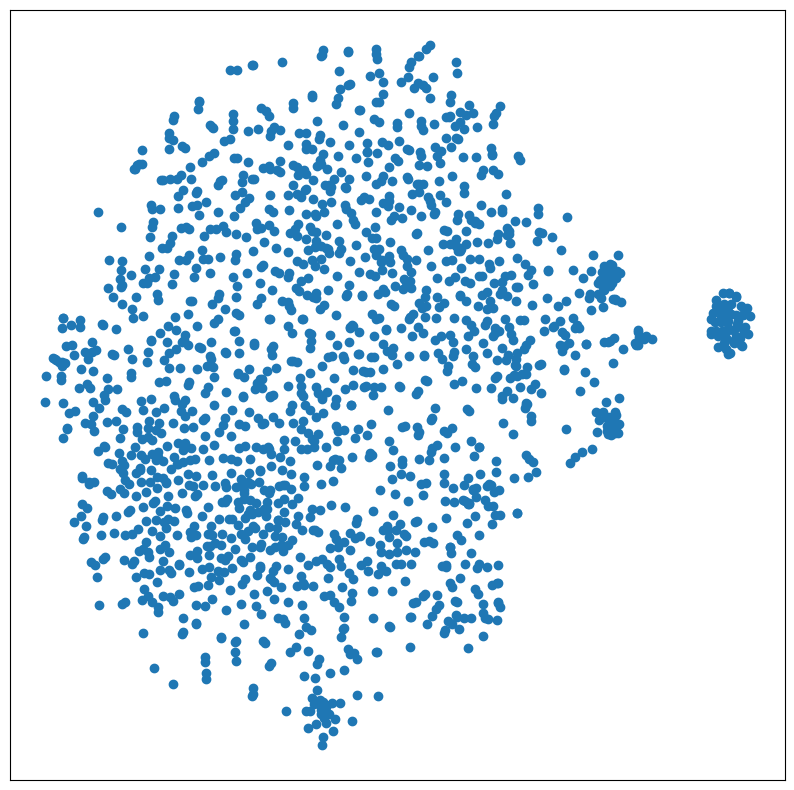

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.scatter(item_tsne[:, 0], item_tsne[:, 1]);
plt.xticks(()); plt.yticks(());
plt.show()

In [141]:
import plotly.express as px

tsne_df = pd.DataFrame(item_tsne, columns=["tsne_1", "tsne_2"])
tsne_df["item_id"] = np.arange(item_tsne.shape[0])
tsne_df = tsne_df.merge(items.reset_index())

px.scatter(tsne_df, x="tsne_1", y="tsne_2",
           color="popularity",
           hover_data=["item_id", "title", "popularity"])

### Exercises

 - Add another layer to the neural network and retrain, compare train/test error.
 - Try adding more dropout and change layer sizes.


### A recommendation function for a given user

Once the model is trained, the system can be used to recommend a few items for a user that they haven't seen before. The following code does that.

- we use the `model.predict` to compute the ratings a user would have given to all items
- we build a function that sorts these items and excludes those the user has already seen.

In [142]:
def recommend(user_id, top_n=10):
    item_ids = range(1, items['item_id'].max())
    seen_mask = all_ratings["user_id"] == user_id
    seen_movies = set(all_ratings[seen_mask]["item_id"])
    item_ids = list(filter(lambda x: x not in seen_movies, item_ids))

    user = np.zeros_like(item_ids)
    user[:len(item_ids)] = user_id
    items_ = np.array(item_ids)
    ratings = model.predict([user, items_]).flatten()
    top_items = ratings.argsort()[-top_n:][::-1]
    return [(indexed_items.loc[item_id]["title"], ratings[item_id]) for item_id in top_items]

In [143]:
for title, pred_rating in recommend(5):
    print("    %0.1f: %s" % (pred_rating, title))

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
    5.4: Dead Man Walking (1995)
    5.1: Eat Drink Man Woman (1994)
    4.8: Godfather, The (1972)
    4.8: Godfather: Part II, The (1974)
    4.7: Terminator, The (1984)
    4.6: Breaking the Waves (1996)
    4.6: Affair to Remember, An (1957)
    4.6: Supercop (1992)
    4.6: Abyss, The (1989)
    4.6: Get Shorty (1995)


### Exercises

- Try modifying our neural network to improve recommendation. You could try adding more layers, or using a different loss function. 
- Your goal is to improve the Mean Absolute Error on the test set. Show the results of your best model.

In [144]:
class RegressionModel2(Model):
    def __init__(self, embedding_size, max_user_id, max_item_id, dropout_rate=0.5): # I add the dropout rate hyperparameter
        super().__init__()

        self.user_embedding = Embedding(input_dim=max_user_id + 1, output_dim=embedding_size, name='user_embedding')
        self.item_embedding = Embedding(input_dim=max_item_id + 1, output_dim=embedding_size, name='item_embedding')

        self.flatten = Flatten()
        self.dot = Dot(axes=1) # This is where the original stop, only use raw similarity score! 
        
        self.hidden_layer = Dense(64, activation='relu')  # I add a hidden layer to add non-linearity learning capacity.
        self.dropout      = Dropout(dropout_rate)         # I add a dropout layer to prevent overfitting.
        self.output_layer = Dense(1, activation='linear') # Produces the final predicted rating as a continuous value.

    def call(self, inputs):
        user_inputs = inputs[0]
        item_inputs = inputs[1]

        user_vecs = self.flatten(self.user_embedding(user_inputs))
        item_vecs = self.flatten(self.item_embedding(item_inputs))

        dot_product = self.dot([user_vecs, item_vecs])

        x = self.hidden_layer(dot_product)
        x = self.dropout(x)
        y = self.output_layer(x)

        return y

Epoch 1/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1.5365 - val_loss: 0.8254
Epoch 2/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6777 - val_loss: 0.7895
Epoch 3/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4951 - val_loss: 0.7995
Epoch 4/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3922 - val_loss: 0.8162
Epoch 5/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3335 - val_loss: 0.8298
Epoch 6/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2953 - val_loss: 0.8405
Epoch 7/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2669 - val_loss: 0.8435
Epoch 8/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2436 - val_loss: 0.8504
Epoch 9/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2210 - val_loss: 0.8514
Epoch 10/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2030 - val_loss: 0.8497
Epoch 11/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1829 - val_loss: 0.8538
Epoch 12/15
1750/1750 ━━━━━━━━

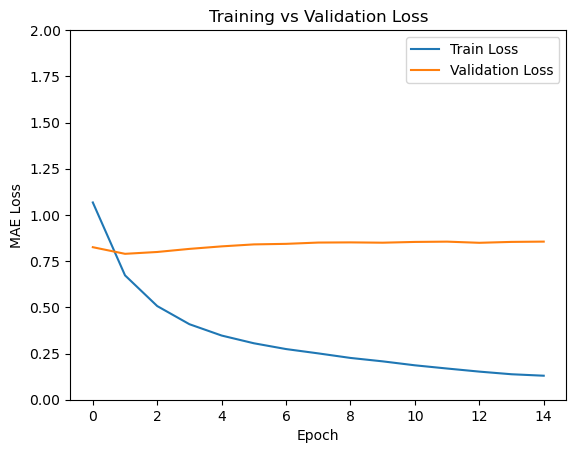

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final test MSE: 1.271
Final test MAE: 0.859


In [151]:
# Training the model
from tensorflow.keras.optimizers import Adam

model2 = RegressionModel2(embedding_size=64, max_user_id=all_ratings['user_id'].max(), max_item_id=all_ratings['item_id'].max(), dropout_rate=0.6)

model2.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

history2 = model2.fit([user_id_train, item_id_train], rating_train, batch_size=32, epochs=15, validation_split=0.3, shuffle=True)


plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.show()

# Evaluate on test set
test_preds = model2.predict([user_id_test, item_id_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))